# **Early Warning System for Student Wellbeing**

**Objective:** To analyze student lifestyle and mental health data and build a system that predicts wellbeing and generates early warning alerts using Machine Learning techniques.

**Tools Used:**
- *Python*
- *Pandas*
- *NumPy*
- *Matplotlib*
- *Scikit-learn*

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/ITTT Project/Student_Health_Dataset.csv')

In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/ITTT Project/Student_Health_Dataset.csv')
df.head()

,student_id,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level
0,100001,23,Male,BTech,1st,4.3,6.8,6.1,High,10,3,4,2,6,1.8,Average,66.5,9.63,Good,High
1,100002,20,Male,BTech,3rd,1.4,4.7,3.0,High,2,10,8,5,9,1.9,Poor,55.8,6.04,Poor,Low
2,100003,24,Female,BCA,4th,3.7,4.8,1.5,Low,2,7,8,6,3,0.8,Good,85.0,8.31,Good,High
3,100004,21,Male,BSc,4th,1.6,6.7,7.0,High,3,3,4,9,9,0.7,Poor,89.1,5.95,Good,High
4,100005,23,Other,BSc,4th,2.0,6.7,5.4,High,7,7,6,4,4,1.7,Good,58.7,8.51,Good,Low


**Data Overview**

The dataset contains student-related features such as sleep, stress, academic load, and mental health indicators. These features will be used to analyze wellbeing and predict risk levels.

In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   student_id               150000 non-null  int64  
 1   age                      150000 non-null  int64  
 2   gender                   150000 non-null  object 
 3   course                   150000 non-null  object 
 4   year                     150000 non-null  object 
 5   daily_study_hours        150000 non-null  float64
 6   daily_sleep_hours        150000 non-null  float64
 7   screen_time_hours        150000 non-null  float64
 8   stress_level             150000 non-null  object 
 9   anxiety_score            150000 non-null  int64  
 10  depression_score         150000 non-null  int64  
 11  academic_pressure_score  150000 non-null  int64  
 12  financial_stress_score   150000 non-null  int64  
 13  social_support_score     150000 non-null  int64  
 14  phys

,student_id,age,daily_study_hours,daily_sleep_hours,screen_time_hours,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,attendance_percentage,cgpa
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,175000.500000,21.000380,5.507869,6.499361,6.502819,5.493907,5.497360,5.507427,5.496027,5.516060,0.998115,75.009528,6.997389
std,43301.414527,2.581216,2.595592,1.443859,3.178948,2.872607,2.869022,2.875524,2.864698,2.870493,0.578866,14.409510,1.732180
min,100001.000000,17.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,50.000000,4.000000
25%,137500.750000,19.000000,3.300000,5.200000,3.700000,3.000000,3.000000,3.000000,3.000000,3.000000,0.500000,62.500000,5.500000
50%,175000.500000,21.000000,5.500000,6.500000,6.500000,5.000000,5.000000,6.000000,6.000000,6.000000,1.000000,75.000000,6.990000
75%,212500.250000,23.000000,7.700000,7.700000,9.300000,8.000000,8.000000,8.000000,8.000000,8.000000,1.500000,87.500000,8.500000
max,250000.000000,25.000000,10.000000,9.000000,12.000000,10.000000,10.000000,10.000000,10.000000,10.000000,2.000000,100.000000,10.000000


**Data Understanding**

- Checked the data types of each column
- Identified numerical and categorical features
- Observed distribution of values

In [ ]:
# Encoding categorical columns

df['stress_level'] = df['stress_level'].map({'Low':1, 'Medium':2, 'High':3})
df['burnout_level'] = df['burnout_level'].map({'Low':1, 'Medium':2, 'High':3})
df['sleep_quality'] = df['sleep_quality'].map({'Poor':1, 'Average':2, 'Good':3})
df['gender'] = df['gender'].map({'Male':0, 'Female':1})
df['internet_quality'] = df['internet_quality'].map({'Poor':1, 'Average':2, 'Good':3})

df.head()

,student_id,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level
0,100001,23,0.0,BTech,1st,4.3,6.8,6.1,3,10,3,4,2,6,1.8,2,66.5,9.63,3,3
1,100002,20,0.0,BTech,3rd,1.4,4.7,3.0,3,2,10,8,5,9,1.9,1,55.8,6.04,1,1
2,100003,24,1.0,BCA,4th,3.7,4.8,1.5,1,2,7,8,6,3,0.8,3,85.0,8.31,3,3
3,100004,21,0.0,BSc,4th,1.6,6.7,7.0,3,3,3,4,9,9,0.7,1,89.1,5.95,3,3
4,100005,23,NaN,BSc,4th,2.0,6.7,5.4,3,7,7,6,4,4,1.7,3,58.7,8.51,3,1


# Data Preprocessing

Categorical values such as stress level, sleep quality, and gender were converted into numerical form using encoding techniques to make the dataset suitable for machine learning models.

In [ ]:
df['wellbeing_score'] = (
    df['daily_sleep_hours'] * 2 +
    df['physical_activity_hours'] * 2 +
    df['social_support_score'] -
    df['stress_level'] -
    df['anxiety_score'] -
    df['depression_score']
)

df.head()

,student_id,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,...,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level,wellbeing_score
0,100001,23,0.0,BTech,1st,4.3,6.8,6.1,3,10,...,4,2,6,1.8,2,66.5,9.63,3,3,7.2
1,100002,20,0.0,BTech,3rd,1.4,4.7,3.0,3,2,...,8,5,9,1.9,1,55.8,6.04,1,1,7.2
2,100003,24,1.0,BCA,4th,3.7,4.8,1.5,1,2,...,8,6,3,0.8,3,85.0,8.31,3,3,4.2
3,100004,21,0.0,BSc,4th,1.6,6.7,7.0,3,3,...,4,9,9,0.7,1,89.1,5.95,3,3,14.8
4,100005,23,NaN,BSc,4th,2.0,6.7,5.4,3,7,...,6,4,4,1.7,3,58.7,8.51,3,1,3.8


# Feature Engineering

A new feature called **wellbeing_score** was created by combining positive and negative factors affecting student wellbeing. This helps in better prediction and analysis.

In [ ]:
def risk_category(score):
    if score > 15:
        return 0   # Safe
    elif score > 10:
        return 1   # Warning
    else:
        return 2   # Critical

df['risk_level'] = df['wellbeing_score'].apply(risk_category)

df.head()

,student_id,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,...,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level,wellbeing_score,risk_level
0,100001,23,0.0,BTech,1st,4.3,6.8,6.1,3,10,...,2,6,1.8,2,66.5,9.63,3,3,7.2,2
1,100002,20,0.0,BTech,3rd,1.4,4.7,3.0,3,2,...,5,9,1.9,1,55.8,6.04,1,1,7.2,2
2,100003,24,1.0,BCA,4th,3.7,4.8,1.5,1,2,...,6,3,0.8,3,85.0,8.31,3,3,4.2,2
3,100004,21,0.0,BSc,4th,1.6,6.7,7.0,3,3,...,9,9,0.7,1,89.1,5.95,3,3,14.8,1
4,100005,23,NaN,BSc,4th,2.0,6.7,5.4,3,7,...,4,4,1.7,3,58.7,8.51,3,1,3.8,2


# Risk Classification

Students were categorized into three risk levels:
- Safe
- Warning
- Critical

This helps us in building an early warning system.

In [ ]:
df.to_csv('/content/drive/MyDrive/ITTT Project/Cleaned_Student_Health_Dataset.csv', index=False)

# Data Visualization and Analysis

In this section, we visualized relationships between different features to understand factors affecting student wellbeing.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

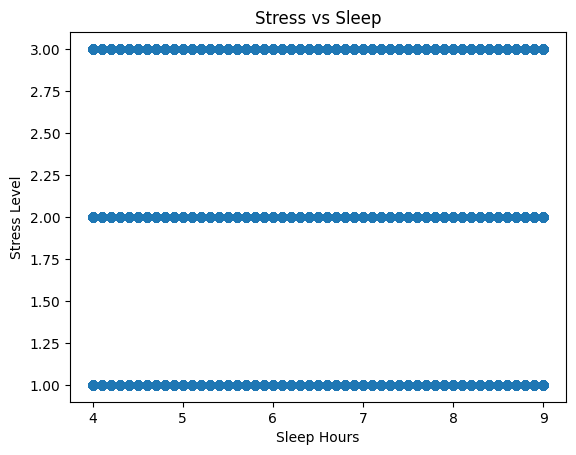

In [ ]:
plt.figure()
plt.scatter(df['daily_sleep_hours'], df['stress_level'])
plt.xlabel("Sleep Hours")
plt.ylabel("Stress Level")
plt.title("Stress vs Sleep")
plt.show()

**Insight:**
The scatter plot shows stress levels across different sleep durations. However, since stress levels are categorical (Low, Medium, High), the data appears in horizontal bands.

No strong linear relationship is observed between sleep hours and stress level from this visualization alone. Further analysis is required to understand their relationship.

In [ ]:
df[['daily_sleep_hours', 'stress_level']].corr()

,daily_sleep_hours,stress_level
daily_sleep_hours,1.000000,-0.001616
stress_level,-0.001616,1.000000


In [ ]:
df.groupby('stress_level')['daily_sleep_hours'].mean()

,daily_sleep_hours
stress_level,
1,6.504104
2,6.495668
3,6.498362


**Additional Analysis:**
Correlation and average analysis were used to better understand relationships between variables where scatter plots were not sufficient.

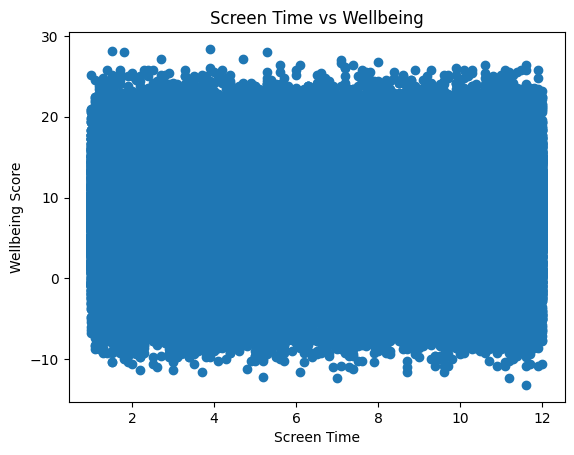

In [ ]:
plt.figure()
plt.scatter(df['screen_time_hours'], df['wellbeing_score'])
plt.xlabel("Screen Time")
plt.ylabel("Wellbeing Score")
plt.title("Screen Time vs Wellbeing")
plt.show()

**Insight:**
The scatter plot shows the relationship between screen time and wellbeing score. However, no clear linear trend is visible, indicating that screen time alone does not strongly determine student wellbeing.

Wellbeing is influenced by multiple factors such as sleep, stress, and physical activity.

In [ ]:
df[['screen_time_hours','wellbeing_score']].corr()

,screen_time_hours,wellbeing_score
screen_time_hours,1.000000,-0.000829
wellbeing_score,-0.000829,1.000000


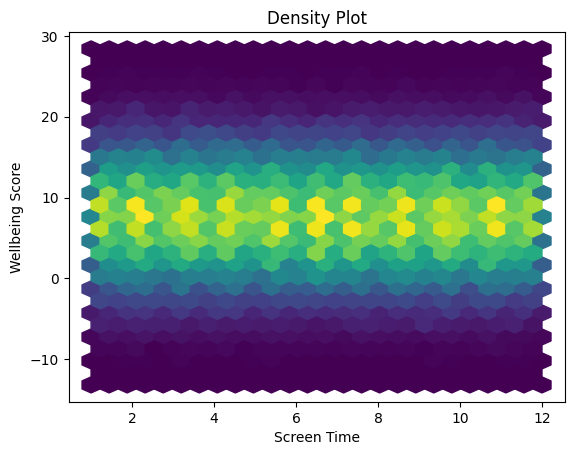

In [ ]:
plt.figure()
plt.hexbin(df['screen_time_hours'], df['wellbeing_score'], gridsize=25)
plt.xlabel("Screen Time")
plt.ylabel("Wellbeing Score")
plt.title("Density Plot")
plt.show()

In [ ]:
important_cols = [
    'daily_sleep_hours',
    'screen_time_hours',
    'stress_level',
    'anxiety_score',
    'depression_score',
    'physical_activity_hours',
    'social_support_score',
    'wellbeing_score'
]

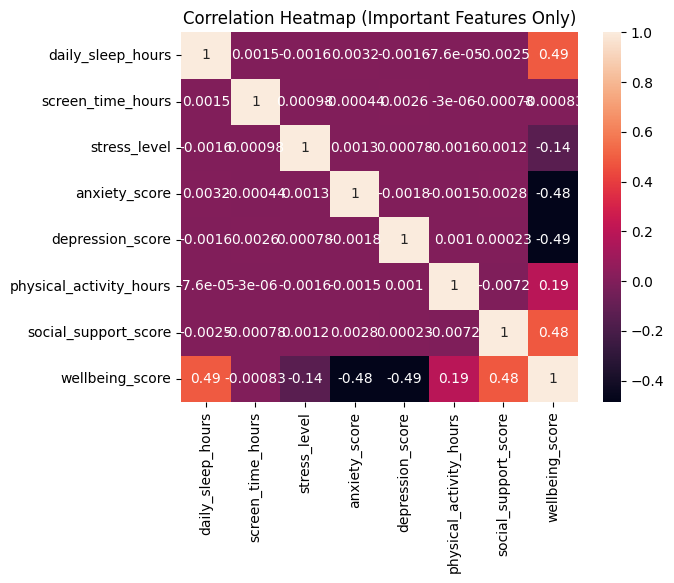

In [ ]:
plt.figure()
sns.heatmap(df[important_cols].corr(), annot=True)
plt.title("Correlation Heatmap (Important Features Only)")
plt.show()

**Insight:**
The correlation heatmap shows relationships between all features. Sleep hours and physical activity have a positive correlation with wellbeing, while stress, anxiety, and depression show negative correlation.

Screen time shows weak correlation, indicating it has less direct impact on wellbeing compared to other factors.

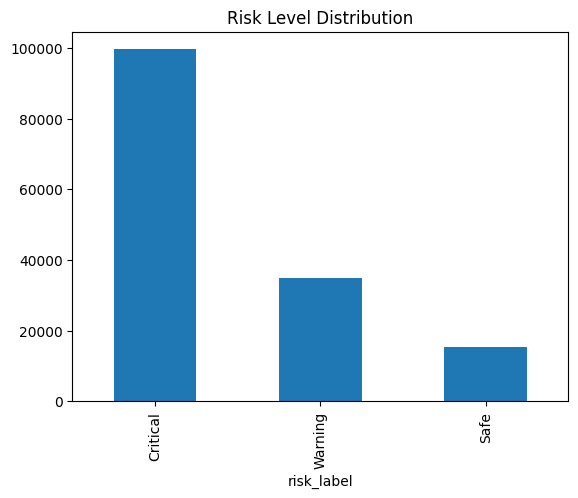

In [ ]:
df['risk_label'] = df['risk_level'].map({
    0: 'Safe',
    1: 'Warning',
    2: 'Critical'
})

df['risk_label'].value_counts().plot(kind='bar')
plt.title("Risk Level Distribution")
plt.show()

**Insight:**
The distribution shows that a large number of students fall under the critical risk category, indicating poor overall wellbeing in the dataset.

This may be due to high stress levels, low sleep hours, or strict threshold conditions used in classification.

# Regression Model

A regression model is used to predict the wellbeing score of students based on various lifestyle and mental health factors.

In [ ]:
from sklearn.model_selection import train_test_split

# Features (X)
X = df[['daily_study_hours','daily_sleep_hours','screen_time_hours',
        'stress_level','anxiety_score','depression_score',
        'physical_activity_hours','social_support_score']]

# Target (y)
y = df['wellbeing_score']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
from sklearn.metrics import mean_squared_error

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 2.9614377436948685e-29


**Insight:**
The Mean Squared Error is extremely low, indicating highly accurate predictions. This is because the wellbeing score was derived from the same features used in the model, leading to a strong linear relationship.

In [ ]:
#On Sample Data

import pandas as pd

new_student = pd.DataFrame([{
    'daily_study_hours': 10,
    'daily_sleep_hours': 6,
    'screen_time_hours': 4,
    'stress_level': 3,
    'anxiety_score': 5,
    'depression_score': 3,
    'physical_activity_hours': 1.5,
    'social_support_score': 5
}])

prediction = model.predict(new_student)
print("Predicted Wellbeing:", prediction)

Predicted Wellbeing: [9.]


# Clustering Model

Clustering is used to group students based on similar wellbeing patterns without predefined labels.

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3)
df['cluster'] = kmeans.fit_predict(X)

cluster
0    10.136997
1     4.865396
2     7.538607
Name: wellbeing_score, dtype: float64


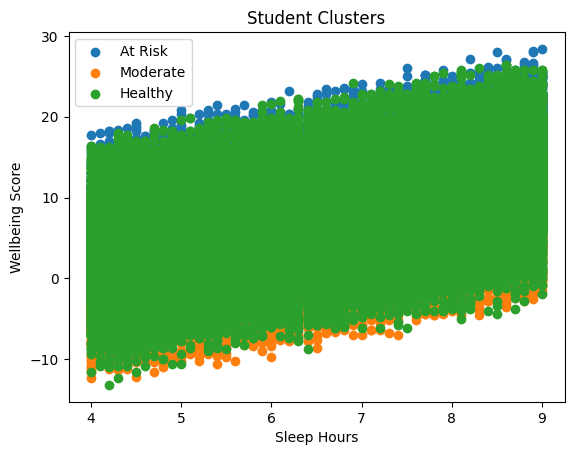

In [ ]:
# Check cluster means
print(df.groupby('cluster')['wellbeing_score'].mean())

# Map labels AFTER checking
df['cluster_label'] = df['cluster'].map({
    0: 'At Risk',
    1: 'Moderate',
    2: 'Healthy'
})

# Plot
plt.figure()

for label in df['cluster_label'].unique():
    subset = df[df['cluster_label'] == label]
    plt.scatter(subset['daily_sleep_hours'], subset['wellbeing_score'], label=label)

plt.xlabel("Sleep Hours")
plt.ylabel("Wellbeing Score")
plt.title("Student Clusters")
plt.legend()
plt.show()

**Insight:**
Clustering grouped students into different categories based on their wellbeing patterns. Students with higher wellbeing scores are grouped together, while those with lower scores form separate clusters.

This helps identify healthy, moderate, and at-risk students without predefined labels.

# Classification Model

A classification model is used to predict the risk level of students (Safe, Warning, Critical).

In [ ]:
y_class = df['risk_level']

X_train, X_test, y_train, y_test = train_test_split(X, y_class, test_size=0.2)

In [ ]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

Accuracy: 1.0


**Insight:**
The classification model predicts whether a student is in a safe, warning, or critical condition. Accuracy shows how well the model performs.

In [ ]:
#On Sample Data

import pandas as pd

new_student = pd.DataFrame([{
    'daily_study_hours': 4,
    'daily_sleep_hours': 6,
    'screen_time_hours': 8,
    'stress_level': 3,
    'anxiety_score': 9,
    'depression_score': 3,
    'physical_activity_hours': 1.5,
    'social_support_score': 5
}])

In [ ]:
prediction = clf.predict(new_student)
print("Predicted Risk Level:", prediction)

Predicted Risk Level: [2]


In [ ]:
risk_label = {0: "Safe", 1: "Warning", 2: "Critical"}

print("Risk:", risk_label[prediction[0]])

Risk: Critical


In [ ]:
probs = clf.predict_proba(new_student)[0]

print(f"Safe: {probs[0]*100:.2f}%")
print(f"Warning: {probs[1]*100:.2f}%")
print(f"Critical: {probs[2]*100:.2f}%")

Safe: 0.00%
Critical: 100.00%


**Feature Importance Analysis**

This section identifies which factors have the most impact on student wellbeing.

In [ ]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.coef_
})

importance = importance.sort_values(by='Importance', ascending=False)
print(importance)

                   Feature    Importance
6  physical_activity_hours  2.000000e+00
1        daily_sleep_hours  2.000000e+00
7     social_support_score  1.000000e+00
2        screen_time_hours  5.551115e-16
0        daily_study_hours  0.000000e+00
3             stress_level -1.000000e+00
5         depression_score -1.000000e+00
4            anxiety_score -1.000000e+00


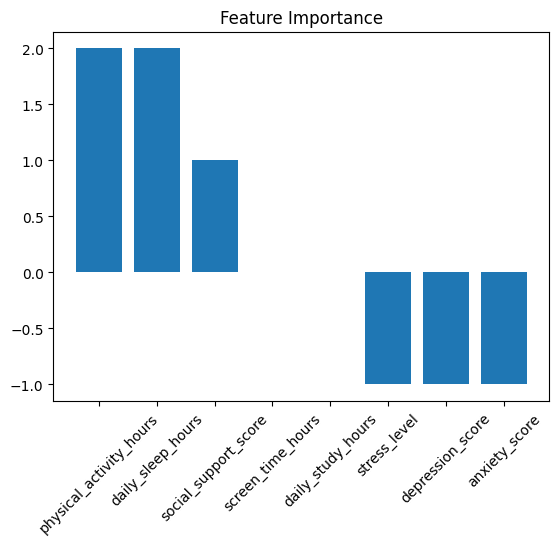

In [ ]:
plt.figure()
plt.bar(importance['Feature'], importance['Importance'])
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.show()

**Insight:**
The graph shows which factors most influence student wellbeing. Sleep and physical activity have a positive impact, while stress and anxiety negatively affect wellbeing.

# **Conclusion**

This project successfully analyzed student wellbeing using machine learning techniques. Regression was used to predict wellbeing scores, clustering grouped students into categories, and classification provided early warning alerts.

The system can help identify students at risk and enable timely intervention.

In [ ]:
import pickle

pickle.dump(model, open('regression_model.pkl', 'wb'))
pickle.dump(clf, open('classification_model.pkl', 'wb'))